In [72]:
import seaborn as sns
import pandas as pd

print(sns.get_dataset_names())

# load the data of titanic
# titanic = sns.load_dataset("titanic")
# titanic = sns.load_dataset("car_crashes")
# titanic = sns.load_dataset("attention")
titanic = sns.load_dataset("anscombe")

# print the first 5 rows
# print(titanic.head())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [73]:
titanic

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


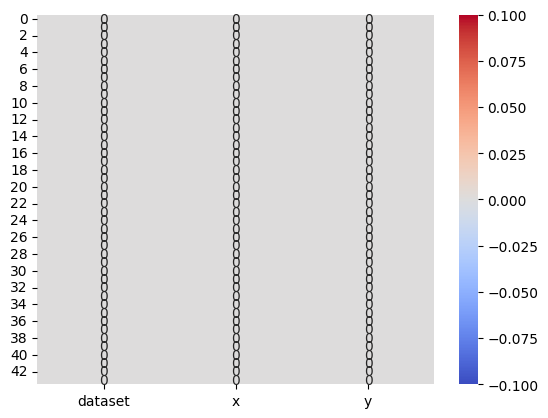

In [74]:
import matplotlib.pyplot as plt
sns.heatmap(titanic.isnull(), annot=True, cmap="coolwarm")
plt.show()


In [75]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for i in titanic.columns:
    if titanic[i].dtype == "object":
        titanic[i] = encoder.fit_transform(titanic[i])
    elif titanic[i].dtype == "float64":
        titanic[i] = encoder.fit_transform(titanic[i])
    elif titanic[i].dtype == "category":
        titanic[i] = encoder.fit_transform(titanic[i])


In [76]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   dataset  44 non-null     int64
 1   x        44 non-null     int64
 2   y        44 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB


In [77]:
from sklearn.impute import KNNImputer
import pandas as pd

imputer = KNNImputer(n_neighbors=5)

# KNNImputer requires only numeric columns. Select only numeric columns for imputation.
numeric_cols = titanic.select_dtypes(include=["number", "bool"]).columns
titanic[numeric_cols] = imputer.fit_transform(titanic[numeric_cols])
titanic = pd.DataFrame(titanic, columns=titanic.columns)





In [78]:
titanic

,dataset,x,y
0,0.0,6.0,26.0
1,0.0,4.0,16.0
2,0.0,9.0,22.0
3,0.0,5.0,34.0
4,0.0,7.0,30.0
5,0.0,10.0,39.0
6,0.0,2.0,19.0
7,0.0,0.0,1.0
8,0.0,8.0,40.0
9,0.0,3.0,3.0


In [79]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
  

iterativeImputer = IterativeImputer()

titanic = pd.DataFrame(iterativeImputer.fit_transform(titanic))

In [80]:
titanic

,0,1,2
0,0.0,6.0,26.0
1,0.0,4.0,16.0
2,0.0,9.0,22.0
3,0.0,5.0,34.0
4,0.0,7.0,30.0
5,0.0,10.0,39.0
6,0.0,2.0,19.0
7,0.0,0.0,1.0
8,0.0,8.0,40.0
9,0.0,3.0,3.0


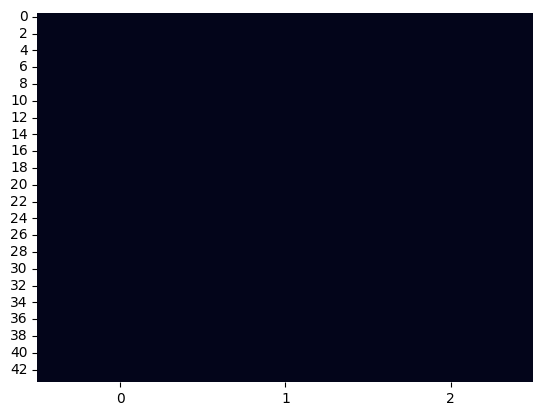

In [81]:
sns.heatmap(titanic.isnull(),cbar=False)
plt.show()